# CBR Legal Case Retrieval System

Nama : Ach Sofyan Daynur
NIM : 202110370311155

Implementasi Case-Based Reasoning (CBR) untuk Retrieval Kasus Hukum Menggunakan TF-IDF dan Cosine Similarity

# 03 Case Retrieval

Tahap Retrieval pada Case-Based Reasoning (CBR) digunakan untuk mencari kasus yang paling mirip dengan kasus baru.

Metode yang digunakan:

- TF-IDF Vectorization
- Cosine Similarity
- Top-K Retrieval (K=5)

Representasi kasus dibentuk dari:

- Ringkasan Fakta
- Pasal
- Jenis Perkara

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!rm -rf /content/CBR-Legal-Case
!cp -r "/content/drive/MyDrive/CBR-Legal-Case" /content/

cp: cannot open '/content/drive/MyDrive/CBR-Legal-Case/notebooks/README.md.gdoc' for reading: Operation not supported


In [3]:
%cd /content/CBR-Legal-Case

/content/CBR-Legal-Case


Cell 1 — Import Library

In [6]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

Cell 2 — Load Dataset

In [7]:
import pandas as pd

df = pd.read_csv(
    "/content/CBR-Legal-Case/data/processed/cases.csv"
)

print("Jumlah kasus:", len(df))

display(
    df[
        [
            "case_id",
            "nomor_putusan",
            "tahun",
            "pengadilan",
            "jenis_perkara",
            "pihak"
        ]
    ].head()
)

Jumlah kasus: 30


,case_id,nomor_putusan,tahun,pengadilan,jenis_perkara,pihak
0,putusan 11,961/PID.SUS/2026/PT,2026,Pengadilan Tinggi Surabaya,Pidana Khusus,MOHAMMAD BEDRUN BIN SAMHERI
1,putusan 8,296/PID.SUS/2026/PT,2026,Pengadilan Tinggi Palembang,Pidana Khusus,ISKANDAR AK BIN ABU KOSIM
2,putusan 28,99/Pid,Tidak ditemukan,Pengadilan Tinggi Medan,Tidak diketahui,Tidak ditemukan
3,putusan 20,53/,Tidak ditemukan,Pengadilan Tinggi Ambon,Pidana Khusus,Tidak ditemukan
4,putusan 18,2281,Tidak ditemukan,Pengadilan Tinggi Yogyakarta,Pidana Khusus,Tidak ditemukan


Cell 3 - Membentuk Case Representation


In [8]:
df["case_representation"] = (
    (df["pasal"].fillna("") + " ") * 3 +
    df["ringkasan_fakta"].fillna("")
)

df[
    ["case_id", "case_representation"]
].head()

,case_id,case_representation
0,putusan 11,"Pasal 609, Pasal 114, pasal 114, pasal 14 Pasa..."
1,putusan 8,"Pasal 609, Pasal 25, pasal 80, Pasal\n609, Pas..."
2,putusan 28,"Pasal\n114, Pasal 132, Pasal 112 Pasal\n114, P..."
3,putusan 20,"Pasal 112, Pasal 127, Pasal 114 Pasal 112, Pas..."
4,putusan 18,"Pasal\n114, Pasal 132, Pasal 127, Pasal\n112 P..."


Cell 4 - TF-IDF Vectorization

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=[
        "yang", "dan", "atau", "dengan",
        "bahwa", "terdakwa", "menimbang",
        "oleh", "untuk", "dalam", "pada",
        "telah", "adalah", "sebagai",
        "perkara", "putusan", "pengadilan"
    ]
)

tfidf_matrix = vectorizer.fit_transform(
    df["case_representation"]
)

print("Shape TF-IDF Matrix:")
print(tfidf_matrix.shape)

print("\nJumlah fitur:")
print(len(vectorizer.get_feature_names_out()))

Shape TF-IDF Matrix:
(30, 816)

Jumlah fitur:
816


Cell 5 - Cosine Similarity Matrix

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

print("Shape Similarity Matrix:")
print(similarity_matrix.shape)

Shape Similarity Matrix:
(30, 30)


In [11]:
similarity_matrix.shape

(30, 30)

Cell 6 - Fungsi Retrieval

In [12]:
def retrieve_cases(case_id, top_k=5):

    idx = df[
        df["case_id"] == case_id
    ].index[0]

    similarities = similarity_matrix[idx]

    similar_indices = similarities.argsort()[::-1]

    results = []

    for i in similar_indices:

        if i == idx:
            continue

        results.append({
            "case_id": df.iloc[i]["case_id"],
            "similarity_score": round(similarities[i], 4),
            "pasal": df.iloc[i]["pasal"]
        })

    return pd.DataFrame(results).head(top_k)

Cell 7 - Uji Retrieval

In [13]:
case_id = "putusan 11"

print("QUERY CASE")
print(case_id)

retrieve_cases(
    case_id=case_id,
    top_k=5
)

QUERY CASE
putusan 11


,case_id,similarity_score,pasal
0,putusan 19,0.4209,"Pasal 112, Pasal 127, Pasal 253, Pasal 114"
1,putusan 21,0.4043,"Pasal 112, Pasal 114"
2,PUTUSAN 5,0.3139,"Pasal 609, Pasal 127, Pasal 127, Pasal 114"
3,putusan 14,0.2741,"Pasal 112, Pasal 127, Pasal 114"
4,PUTUSAN 6,0.2301,"Pasal 609, Pasal 114"


Cell 8 — Detail Query

In [14]:
query_index = 0

print("="*80)
print("DETAIL QUERY")
print("="*80)

print("CASE ID:")
print(df.iloc[query_index]["case_id"])

print("\nPASAL:")
print(df.iloc[query_index]["pasal"])

print("\nRINGKASAN FAKTA:")
print(df.iloc[query_index]["ringkasan_fakta"][:500])

DETAIL QUERY
CASE ID:
putusan 11

PASAL:
Pasal 609, Pasal 114, pasal 114, pasal 14

RINGKASAN FAKTA:
Terdakwa diajukan ke persidangan oleh Kejaksaan Negeri Sampang didakwa dengan dakwaan yang berbentuk dakwaan Alternatif sebagai berikut: KESATU Perbuatan terdakwa sebagaimana diatur dan diancam pidana dalam pasal 114 ayat (1) Undang-Undang Nomor 35 Tahun 2009 tentang Narkotika Jo UU RI No. 1 tahun 2023 tentang KUHP Jo. UU No. 1 tahun 2026 tentang Penyesuaian tindak pidana. ATAU KEDUA : Perbuatan terdakwa sebagaimana diatur dan diancam pidana dalam Pasal 609 ayat (1) huruf a Undang-Undang RI Nomo


Cell 9 — Top 5 Similar Cases

In [15]:
retrieve_cases(
    "putusan 11",
    top_k=5
)

,case_id,similarity_score,pasal
0,putusan 19,0.4209,"Pasal 112, Pasal 127, Pasal 253, Pasal 114"
1,putusan 21,0.4043,"Pasal 112, Pasal 114"
2,PUTUSAN 5,0.3139,"Pasal 609, Pasal 127, Pasal 127, Pasal 114"
3,putusan 14,0.2741,"Pasal 112, Pasal 127, Pasal 114"
4,PUTUSAN 6,0.2301,"Pasal 609, Pasal 114"


Cell 10 — Generate Predictions

In [16]:
predictions = []

for case_id in df["case_id"]:

    result = retrieve_cases(
        case_id,
        top_k=1
    )

    predictions.append({
        "query_case": case_id,
        "top_1_result": result.iloc[0]["case_id"],
        "similarity_score": result.iloc[0]["similarity_score"]
    })

predictions_df = pd.DataFrame(predictions)

predictions_df.head()

,query_case,top_1_result,similarity_score
0,putusan 11,putusan 19,0.4209
1,putusan 8,putusan 10,0.7844
2,putusan 28,PUTUSAN 5,0.3064
3,putusan 20,putusan 8,0.3414
4,putusan 18,putusan 16,0.3616


Cell 11 — Simpan Predictions

In [ ]:
predictions_df.to_csv(
    "/content/CBR-Legal-Case/data/results/predictions.csv",
    index=False
)

print("predictions.csv berhasil disimpan")

predictions.csv berhasil disimpan


Cell 13 - Preview Predictions

In [ ]:
print(predictions_df.shape)

predictions_df.head(10)

(30, 3)


,query_case,top_1_result,similarity_score
0,putusan 11,putusan 19,0.4209
1,putusan 8,putusan 10,0.7844
2,putusan 28,PUTUSAN 5,0.3064
3,putusan 20,putusan 8,0.3414
4,putusan 18,putusan 16,0.3616
5,putusan 24,PUTUSAN 5,0.2909
6,PUTUSAN 3,PUTUSAN 4,0.2482
7,PUTUSAN 2,putusan 10,0.3977
8,putusan 10,putusan 8,0.7844
9,putusan 15,putusan 23,0.6855


Cell 14 - visual

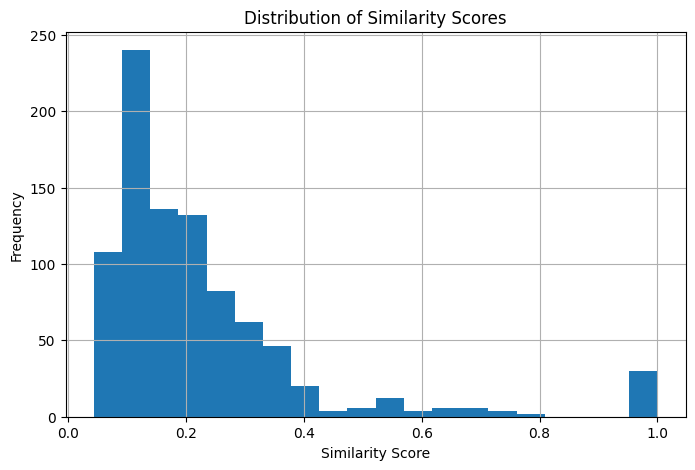

In [ ]:
import matplotlib.pyplot as plt

scores = similarity_matrix.flatten()

plt.figure(figsize=(8,5))

plt.hist(scores, bins=20)

plt.title("Distribution of Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

Cell 15 - Kesimpulan

# Conclusion

Pada tahap Case Retrieval, setiap kasus hukum direpresentasikan menggunakan kombinasi pasal dan ringkasan fakta. Representasi kasus kemudian diubah menjadi vektor numerik menggunakan TF-IDF Vectorization.

Kemiripan antar kasus dihitung menggunakan Cosine Similarity untuk menemukan kasus yang paling relevan terhadap suatu query kasus.

Hasil retrieval menunjukkan bahwa sistem mampu menemukan kasus-kasus dengan karakteristik hukum yang serupa berdasarkan pasal yang digunakan dan fakta perkara yang terkandung dalam putusan.

Output dari tahap ini berupa daftar kasus serupa dan file predictions.csv yang akan digunakan pada tahap evaluasi.

In [4]:
!cp -r /content/CBR-Legal-Case /content/drive/MyDrive/

In [5]:
!ls /content/drive/MyDrive/CBR-Legal-Case

data  notebooks  README.md
